In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


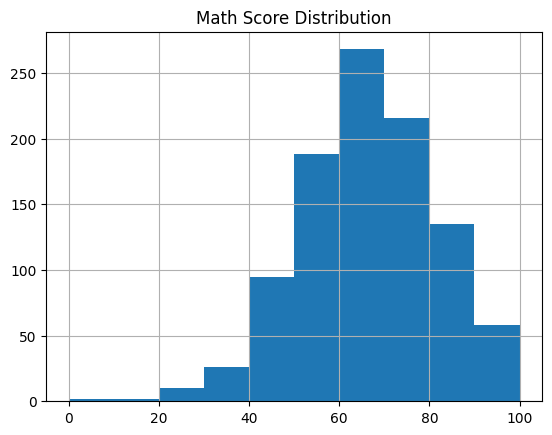

In [7]:
import matplotlib.pyplot as plt

df['math score'].hist()

plt.title("Math Score Distribution")

plt.show()

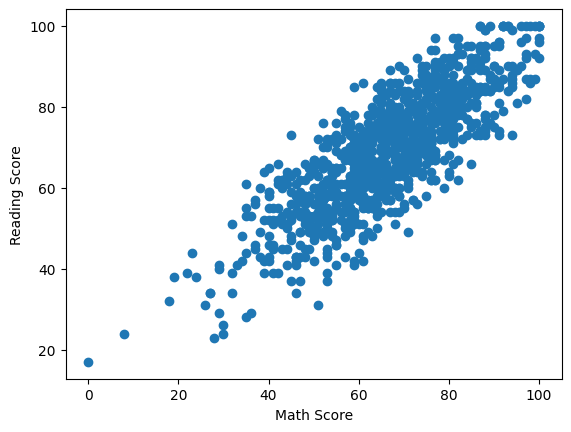

In [8]:
plt.scatter(df['math score'], df['reading score'])

plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.show()

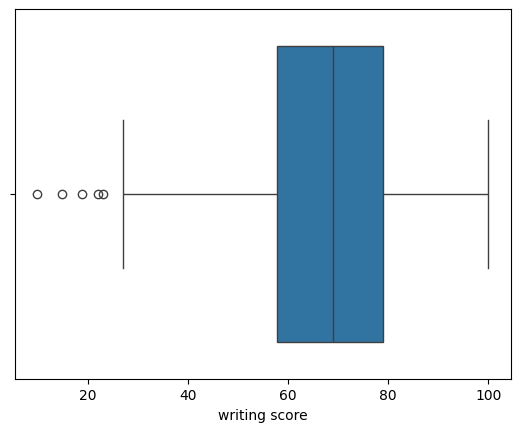

In [10]:
import seaborn as sns

sns.boxplot(x=df['writing score'])

plt.show()

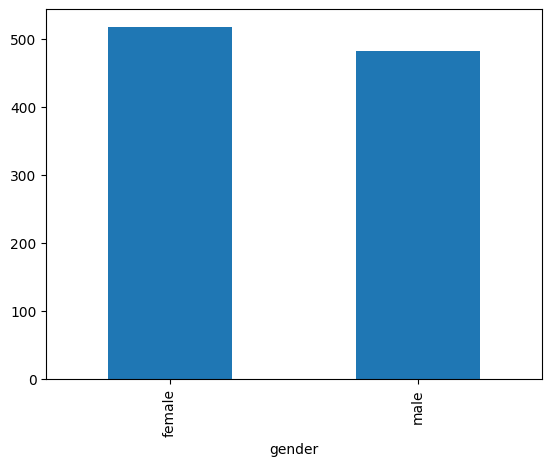

In [11]:
df['gender'].value_counts().plot(kind='bar')

plt.show()

In [13]:
df['average'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

df['result'] = df['average'].apply(
    lambda x: 1 if x >= 50 else 0
)

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [15]:
X = df.drop('result', axis=1)

y = df['result']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0


In [20]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


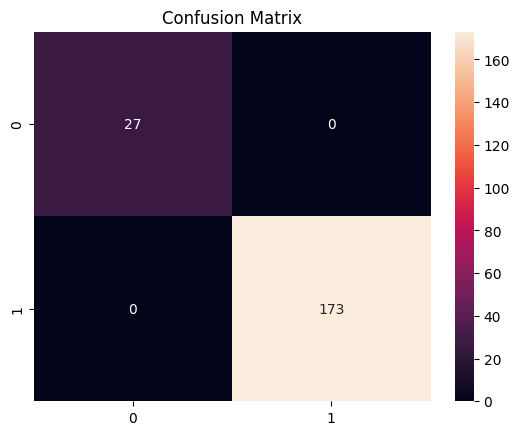

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()